### Importación de librerías y carga del pipeline

In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Cargar datos del paso anterior
with open('../data/mongo_export.json', 'r') as f:
    datos = json.load(f)

df = pd.json_normalize(datos)

# Limpieza rápida de nombres
df = df.rename(columns={
    'hotel.type': 'hotel_type',
    'customer.type': 'customer_type',
    'booking_info.adr': 'adr',
    'booking_info.lead_time': 'lead_time',
    'booking_info.status': 'status',
    'booking_info.guests.adults': 'adults'
})

print(f"Datos listos para Machine Learning: {df.shape[0]} registros.")

Datos listos para Machine Learning: 119390 registros.


### Definición del Target y Train-Test Split

In [3]:
# 2. Definir la variable objetivo (Target)
# Convertimos 'status' (Active/Canceled) a valores binarios (0 y 1)
df['is_canceled'] = df['status'].apply(lambda x: 1 if x == 'Canceled' else 0)

# 3. Seleccionar las variables predictoras (Features)
# Qué variables creemos que influyen en que alguien cancele
features_num = ['lead_time', 'adr', 'adults']
features_cat = ['hotel_type', 'customer_type']

X = df[features_num + features_cat]
y = df['is_canceled']

# 4. División de datos (80% entrenamiento, 20% prueba)
# Usamos stratify=y para mantener la misma proporción de cancelaciones en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Registros para Entrenar: {X_train.shape[0]}")
print(f"Registros para Probar: {X_test.shape[0]}")

Registros para Entrenar: 95512
Registros para Probar: 23878


### Creación del Pipeline y Entrenamiento

In [4]:
# 5. Preprocesamiento Profesional
# - StandardScaler: Normaliza los números (lead_time, adr) para que no tengan escalas locas.
# - OneHotEncoder: Convierte el texto (hotel_type) en columnas binarias (0s y 1s) que el modelo entiende.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ])

# 6. Definir el Modelo: Random Forest
modelo_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10))
])

# 7. ¡Entrenamiento!
print("Entrenando el modelo Random Forest...")
modelo_rf.fit(X_train, y_train)
print("¡Entrenamiento completado exitosamente!")

Entrenando el modelo Random Forest...
¡Entrenamiento completado exitosamente!


### Evaluación y Matriz de Confusión

--- REPORTE DE CLASIFICACIÓN ---
                precision    recall  f1-score   support

No Cancela (0)       0.82      0.63      0.71     15033
Sí Cancela (1)       0.55      0.76      0.64      8845

      accuracy                           0.68     23878
     macro avg       0.68      0.70      0.67     23878
  weighted avg       0.72      0.68      0.68     23878



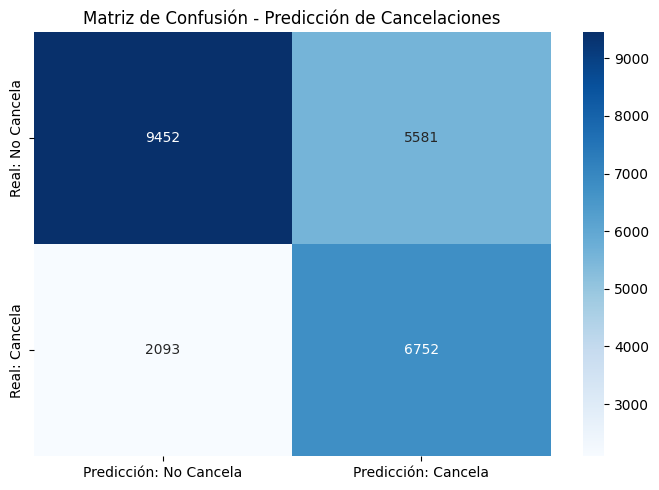

   MÉTRICAS DE LA MATRIZ DE CONFUSIÓN
  Total clientes evaluados : 23,878
  Predicciones correctas   : 16,204
  Predicciones incorrectas : 7,674
  Exactitud     : 16,204 / 23,878 = 67.9%
  Precisión     : 6,752 / 12,333 = 54.7%
  Exhaustividad : 6,752 / 8,845 = 76.3%


In [ ]:
# 8. Realizar predicciones con el set de prueba (que el modelo nunca ha visto)
y_pred = modelo_rf.predict(X_test)

# 9. Imprimir métricas de evaluación
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['No Cancela (0)', 'Sí Cancela (1)']))

# 10. Matriz de Confusión (Visual)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicción: No Cancela', 'Predicción: Cancela'], 
            yticklabels=['Real: No Cancela', 'Real: Cancela'])
plt.title('Matriz de Confusión - Predicción de Cancelaciones')
plt.tight_layout()
plt.savefig('../reports/matriz_confusion.png', dpi=300)
plt.show()

# 11. Métricas detalladas de la Matriz de Confusión
TN, FP, FN, TP = cm.ravel()
total = TN + FP + FN + TP

exactitud   = (TP + TN) / total
precision   = TP / (TP + FP)
exhaustividad = TP / (TP + FN)

print("=" * 45)
print("   MÉTRICAS DE LA MATRIZ DE CONFUSIÓN")
print("=" * 45)
print(f"  Total clientes evaluados : {total:,}")
print(f"  Predicciones correctas   : {TP + TN:,}")
print(f"  Predicciones incorrectas : {FP + FN:,}")
print("=" * 45)
print(f"  Exactitud     : {TP + TN:,} / {total:,} = {exactitud:.1%}")
print(f"  Precisión     : {TP:,} / {TP + FP:,} = {precision:.1%}")
print(f"  Exhaustividad : {TP:,} / {TP + FN:,} = {exhaustividad:.1%}")
print("=" * 45)